In [360]:
import pandas
import matplotlib.pyplot as plt
import numpy
import seaborn as sns


## Import and Check the data

In [361]:
# Load the dataset
df = pandas.read_csv('car_price_prediction.csv')

In [362]:
# Check the first few rows of the dataset
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [363]:
# Check the column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [364]:
# Simplify column names for easier access
df = df.rename(columns={
    'ID': 'id',
    'Price': 'price',
    'Levy': 'levy',
    'Manufacturer': 'manufacturer',
    'Model': 'model',
    'Prod. year': 'year',
    'Category': 'category',
    'Leather interior': 'leather_interior',
    'Fuel type': 'fuel',
    'Engine volume': 'engine_volume',
    'Mileage': 'mileage',
    'Cylinders': 'cylinders',
    'Gear box type': 'gear_type',
    'Drive wheels': 'drive_wheels',
    'Doors': 'doors',
    'Wheel': 'wheel',
    'Color': 'color',
    'Airbags': 'airbags'
})

# Quick check
df.columns

Index(['id', 'price', 'levy', 'manufacturer', 'model', 'year', 'category',
       'leather_interior', 'fuel', 'engine_volume', 'mileage', 'cylinders',
       'gear_type', 'drive_wheels', 'doors', 'wheel', 'color', 'airbags'],
      dtype='str')

# Clean the data
To make the data usable for training. We begin by removing faulty prices.

1. levy - clear character symbols from dataset. change to numeric.
2. mileage - clear 'km' unit and change to numeric.
3. manufacturer - map the text values to numeric replacements.
4. fuel - map the text values to numeric replacements
5. category - map the text values to numeric replacements
6. gear_type - map the text values to numeric replacements
7. engine_volume - clear character data.

In [365]:
# 1) levy: remove '-' and convert to numeric
df['levy'] = df['levy'].replace('-', 0)
df['levy'] = pandas.to_numeric(df['levy'], errors='coerce')

In [366]:
# Sanitize outliers in 'price' and 'levy' columns to improve model performance.
df = df[(df["price"] > 100) & (df["price"] < 600000) ]

In [367]:
# 2) mileage: remove 'km' and separators, then convert to numeric
df['mileage'] = (
    df['mileage']
    .astype(str)
    .str.replace('km', '', regex=False)
    .str.strip()
)
df['mileage'] = pandas.to_numeric(df['mileage'], errors='coerce')

In [368]:

# 3) manufacturer: map text values to numeric codes
# Sort manufacturers by mean price.
manufacturer_sorted = (
    df.groupby('manufacturer')['price']
    .mean()
    .sort_values()
    .index
 )

# 1. `enumerate(...)`: Assigns an integer index to each unique manufacturer, starting from 1.
# 2. `{name: code for code, name in ...}`: Create a mapping where each unique manufacturer (name) is mapped to its corresponding index (code).
manufacturer_map = {name: code for code, name in enumerate(manufacturer_sorted, start=1)}
df['manufacturer'] = df['manufacturer'].map(manufacturer_map)

print("Manufacturers ordered by median price (lowest to highest):")
print(manufacturer_map)

Manufacturers ordered by median price (lowest to highest):
{'ROLLS-ROYCE': 1, 'ROVER': 2, 'ZAZ': 3, 'MOSKVICH': 4, 'VAZ': 5, 'SEAT': 6, 'UAZ': 7, 'DAIHATSU': 8, 'ACURA': 9, 'PONTIAC': 10, 'GMC': 11, 'SAAB': 12, 'DAEWOO': 13, 'OPEL': 14, 'DODGE': 15, 'CHRYSLER': 16, 'ISUZU': 17, 'MAZDA': 18, 'ALFA ROMEO': 19, 'GREATWALL': 20, 'SUBARU': 21, 'VOLVO': 22, 'NISSAN': 23, 'GAZ': 24, 'CITROEN': 25, 'BUICK': 26, 'FIAT': 27, 'RENAULT': 28, 'VOLKSWAGEN': 29, 'SUZUKI': 30, 'LANCIA': 31, 'MERCURY': 32, 'PEUGEOT': 33, 'CADILLAC': 34, 'MITSUBISHI': 35, 'LINCOLN': 36, 'SATURN': 37, 'AUDI': 38, 'TOYOTA': 39, 'CHEVROLET': 40, 'HAVAL': 41, 'SKODA': 42, 'KIA': 43, 'FORD': 44, 'HONDA': 45, 'SCION': 46, 'MINI': 47, 'სხვა': 48, 'MERCEDES-BENZ': 49, 'LEXUS': 50, 'MASERATI': 51, 'INFINITI': 52, 'BMW': 53, 'HYUNDAI': 54, 'JEEP': 55, 'SSANGYONG': 56, 'JAGUAR': 57, 'HUMMER': 58, 'PORSCHE': 59, 'TESLA': 60, 'ASTON MARTIN': 61, 'LAND ROVER': 62, 'FERRARI': 63, 'BENTLEY': 64}


In [369]:
# 4) fuel: map text values to numeric codes
fuel_type_sorted = (
    df.groupby('fuel')['price']
    .median()
    .sort_values()
    .index
)
fuel_map = {name: code for code, name in enumerate(fuel_type_sorted, start=1)}
df['fuel'] = df['fuel'].map(fuel_map)

print("Unique fuel types and their codes:")
print(fuel_map)


Unique fuel types and their codes:
{'CNG': 1, 'Hybrid': 2, 'LPG': 3, 'Petrol': 4, 'Hydrogen': 5, 'Diesel': 6, 'Plug-in Hybrid': 7}


In [370]:
# 5) category: map text values to numeric codes
# Similar to manufacturer mapping, we create a mapping for the 'category' column.
category_sorted = (
    df.groupby('category')['price']
    .median()
    .sort_values()
    .index
)

category_map = {name: code for code, name in enumerate(category_sorted, start=1)}
df['category'] = df['category'].map(category_map)

print("Unique categories and their codes:")
print(category_map)

Unique categories and their codes:
{'Goods wagon': 1, 'Limousine': 2, 'Hatchback': 3, 'Sedan': 4, 'Coupe': 5, 'Microbus': 6, 'Universal': 7, 'Minivan': 8, 'Cabriolet': 9, 'Jeep': 10, 'Pickup': 11}


In [371]:
# 6) gear_type: map text values to numeric codes
gear_type_map = {v: i for i, v in enumerate(sorted(df['gear_type'].dropna().unique()))}
df['gear_type'] = df['gear_type'].map(gear_type_map)

print("Unique gear types and their codes:")
print(gear_type_map)

Unique gear types and their codes:
{'Automatic': 0, 'Manual': 1, 'Tiptronic': 2, 'Variator': 3}


In [372]:
# 7) engine_volume: remove str and convert to numeric
df['engine_volume'] = (
    df['engine_volume']
    .astype(str)
    .str.replace('Turbo', '', regex=False)
    .str.strip()
)
df['engine_volume'] = pandas.to_numeric(df['engine_volume'], errors='coerce')

In [373]:
# Validate cleaned columns
df[['levy', 'mileage', 'manufacturer', 'fuel', 'category', 'gear_type', 'engine_volume']].info()

<class 'pandas.DataFrame'>
Index: 18853 entries, 0 to 19236
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   levy           18853 non-null  int64  
 1   mileage        18853 non-null  int64  
 2   manufacturer   18853 non-null  int64  
 3   fuel           18853 non-null  int64  
 4   category       18853 non-null  int64  
 5   gear_type      18853 non-null  int64  
 6   engine_volume  18853 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 1.2 MB


## Visualise the data
To understand which features are likely to influence our target variable (price)

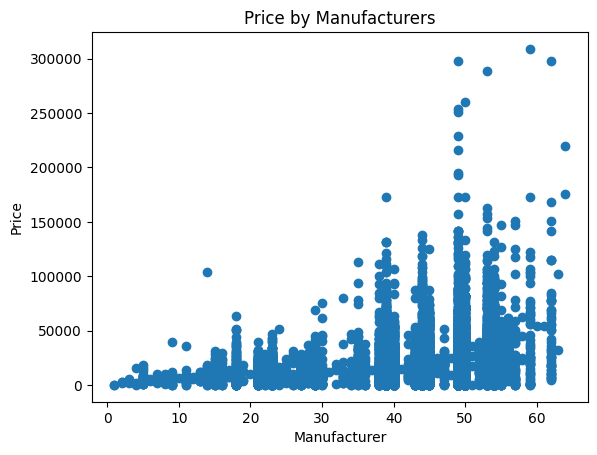

In [374]:
# Scatter plot price against manufacturer
mf_plot = df[df['price']<600000][['manufacturer', 'price']].copy()

plt.scatter(mf_plot['manufacturer'], mf_plot['price'])
plt.title('Price by Manufacturers')
plt.xlabel("Manufacturer")
plt.ylabel("Price")

plt.show()

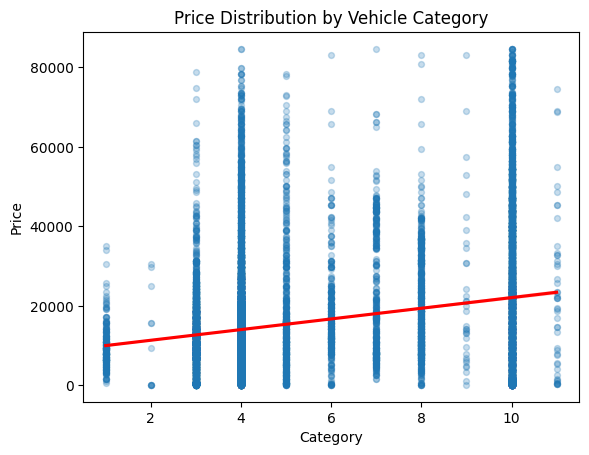

In [375]:
# Plot price with category
cat_plot = df[['category', 'price']].dropna().copy()

# Filter out extreme price values for better visualization
price_max = cat_plot['price'].quantile(0.99)
cat_plot = cat_plot[cat_plot['price'] <= price_max]

# Map category codes back to names for plotting
category_inv_map = {code: name for name, code in category_map.items()}
#cat_plot['category'] = cat_plot['category'].map(category_inv_map)


plt.scatter(cat_plot['category'], cat_plot['price'], alpha=0.25, s=18)
sns.regplot(data=cat_plot, x='category', y='price', scatter=False, color='red')
plt.title('Price Distribution by Vehicle Category')
plt.xlabel('Category')
plt.ylabel('Price')

plt.show()

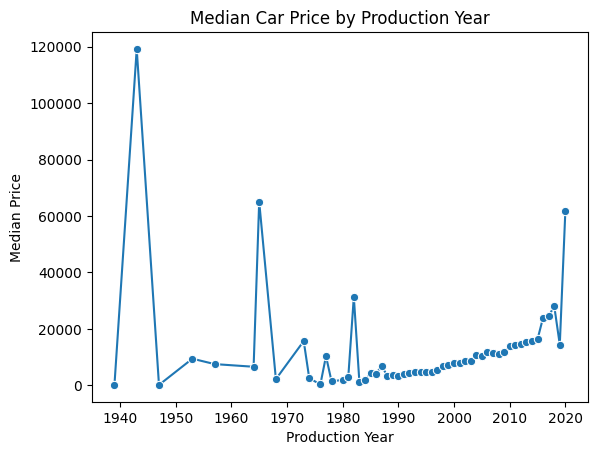

In [376]:
# Plot price with year (median trend)
year_plot = df[['year', 'price']].dropna().copy()
year_summary = (
    year_plot.groupby('year', as_index=False)['price']
    .median()
    .sort_values('year')
 )

sns.lineplot(data=year_summary, x='year', y='price', marker='o')
plt.title('Median Car Price by Production Year')
plt.xlabel('Production Year')
plt.ylabel('Median Price')

plt.show()

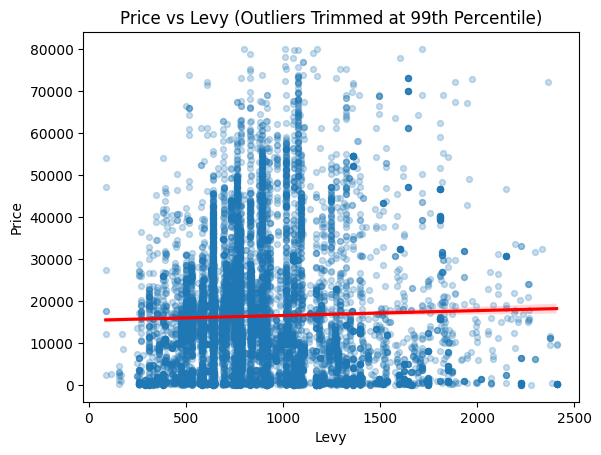

In [377]:
# Plot price with levy
levy_plot = df[['levy', 'price']].dropna().copy()
levy_plot = levy_plot[levy_plot['levy'] > 0]

# Limit extreme outliers for readability
levy_max = levy_plot['levy'].quantile(0.99)
price_max = levy_plot['price'].quantile(0.99)
levy_plot = levy_plot[(levy_plot['levy'] <= levy_max) & (levy_plot['price'] <= price_max)]

plt.scatter(levy_plot['levy'], levy_plot['price'], alpha=0.25, s=18)
sns.regplot(data=levy_plot, x='levy', y='price', scatter=False, color='red')
plt.title('Price vs Levy (Outliers Trimmed at 99th Percentile)')
plt.xlabel('Levy')
plt.ylabel('Price')

plt.show()

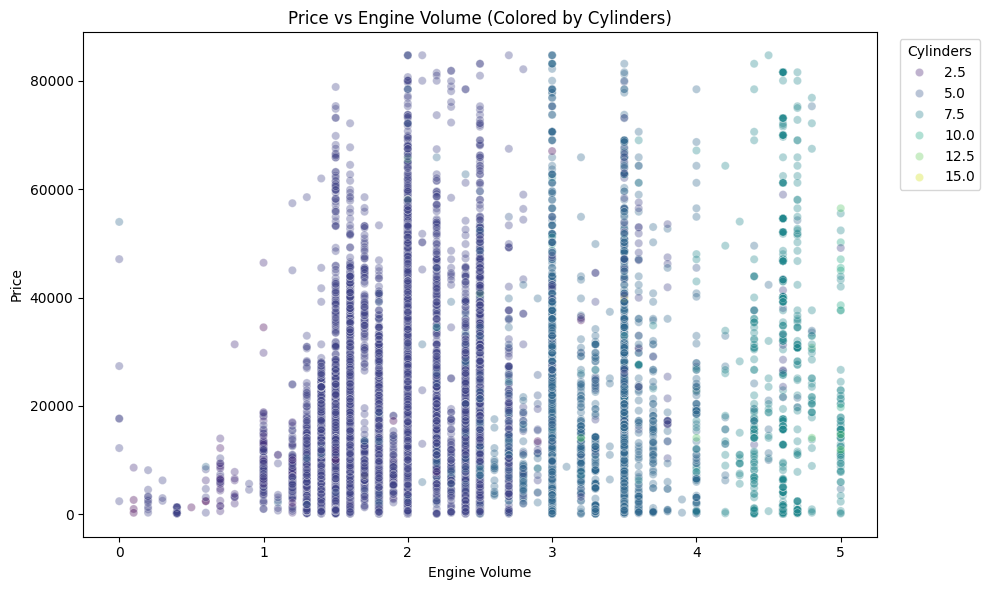

In [378]:
# Plot price with engine volume and cylinders
engine_plot = df[['engine_volume', 'cylinders', 'price']].dropna().copy()
engine_plot['engine_volume_num'] = pandas.to_numeric(
    engine_plot['engine_volume'].astype(str).str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
 )
engine_plot = engine_plot.dropna(subset=['engine_volume_num'])

engine_max = engine_plot['engine_volume_num'].quantile(0.99)
price_max = engine_plot['price'].quantile(0.99)
engine_plot = engine_plot[(engine_plot['engine_volume_num'] <= engine_max) & (engine_plot['price'] <= price_max)]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=engine_plot,
    x='engine_volume_num',
    y='price',
    hue='cylinders',
    palette='viridis',
    alpha=0.35,
    s=35
 )
plt.title('Price vs Engine Volume (Colored by Cylinders)')
plt.xlabel('Engine Volume')
plt.ylabel('Price')
plt.legend(title='Cylinders', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Model Preparation
Select features to use in training model
Decide what kind of model to use

In [379]:
df.columns

Index(['id', 'price', 'levy', 'manufacturer', 'model', 'year', 'category',
       'leather_interior', 'fuel', 'engine_volume', 'mileage', 'cylinders',
       'gear_type', 'drive_wheels', 'doors', 'wheel', 'color', 'airbags'],
      dtype='str')

In [380]:
x = df[['year','levy','manufacturer', 'fuel','engine_volume', 'mileage', 'category']]
y = df['price']

x.info()

<class 'pandas.DataFrame'>
Index: 18853 entries, 0 to 19236
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           18853 non-null  int64  
 1   levy           18853 non-null  int64  
 2   manufacturer   18853 non-null  int64  
 3   fuel           18853 non-null  int64  
 4   engine_volume  18853 non-null  float64
 5   mileage        18853 non-null  int64  
 6   category       18853 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 1.2 MB


In [381]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=61)

In [382]:
x_train.shape

(15082, 7)

In [383]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [384]:
y_pred = model.predict(x_test)

y_pred

array([ 5676.92679487, 40700.64      ,  8197.4559632 , ...,
       18069.61      ,  8875.57      , 18601.98      ], shape=(3771,))

In [385]:
y_test

18789     3136
12179     5645
259       7464
12561     5959
8624     10976
         ...  
5438      5331
1084       549
12437    20385
3493      9000
16310    18660
Name: price, Length: 3771, dtype: int64

## Evaluate Model Performance

In [386]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error,r2_score

In [387]:
mean_absolute_error(y_test, y_pred)

5514.796870345191

In [388]:
root_mean_squared_error(y_test, y_pred)

11795.74162227585